In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr

import equinox as eqx
from flowjax.flows import coupling_flow
from flowjax.distributions import Normal
from flowjax.bijections import Affine, RationalQuadraticSpline
import optax

import tqdm
from types import SimpleNamespace

import numpy as np
import corner
import matplotlib.pyplot as plt

from lisa_sbi_tutorial.training import (
    train_online,
)
from lisa_sbi_tutorial.signal import get_taylor_signal, lisa_asd
from lisa_sbi_tutorial.model import make_model
from lisa_sbi_tutorial.noise import NoiseDataset
from lisa_sbi_tutorial.priors import PriorModel
from lisa_sbi_tutorial.utils import Config


In [2]:
DEFAULT_CONFIG = Config()
    
DEFAULT_CONFIG.nn_depth = 3
print(DEFAULT_CONFIG)

Config(param_dim=2, conditioning_dim=256, flow_layers=6, nn_width=64, nn_depth=3)


In [3]:
priors_dict = {
    "log10_distance_mpc": {"type": "uniform", "min": 4.0, "max": 6.0},
    "log10_mass": {"type": "uniform", "min": 1.0, "max": 3.0}
}

freqs = DEFAULT_CONFIG.freqs
noise_model = NoiseDataset(freqs)
prior_model = PriorModel(priors_dict)

Text(0, 0.5, 'ASD [1/sqrt(Hz)]')

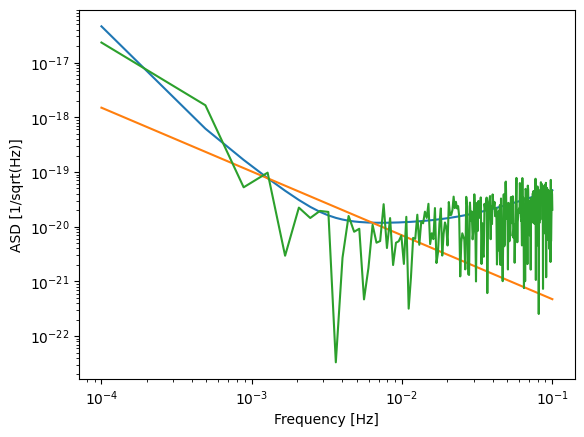

In [4]:
freqs = DEFAULT_CONFIG.freqs
asd = lisa_asd(freqs)
signal = get_taylor_signal(freqs, log10_distance_mpc=jnp.log10(100_000), log10_mass=2.0)
noise = noise_model.sample(jax.random.key(41232), batch_shape=(1,))[0] * asd
data = signal + noise

plt.loglog(freqs, asd)
plt.loglog(freqs, abs(signal))
plt.loglog(freqs, abs(noise))
plt.xlabel("Frequency [Hz]")
plt.ylabel("ASD [1/sqrt(Hz)]")

In [5]:
def whiten_signal(freqs, signal):

    asd = lisa_asd(freqs)

    return signal / asd

def get_true_signal(freqs, theta):

    log10_distance, log10_mass = theta
    
    signal = get_taylor_signal(freqs, log10_distance_mpc=log10_distance, log10_mass=log10_mass)
    return signal

def get_whitened_signal(freqs, theta):

    log10_distance, log10_mass = theta
    
    signal = get_true_signal(freqs, theta)
    return whiten_signal(freqs, signal)


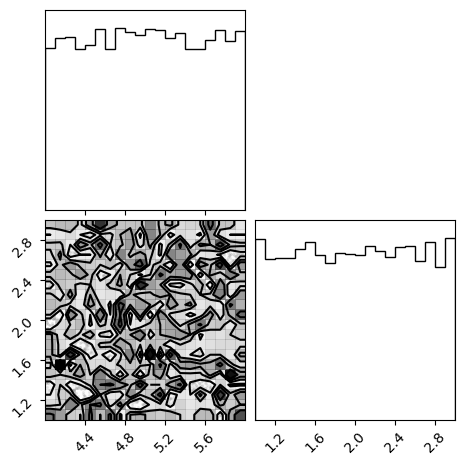

In [6]:
samples = prior_model.sample(jax.random.key(123), batch_shape=(10000,), return_array=True)
corner.corner(
    np.array(samples),
);

In [7]:
experiment = SimpleNamespace(
    noise_model=noise_model,
    prior_model=prior_model,
    simulator=get_whitened_signal,
)

def batch_fn(key, experiment, batch_size):
    
    key, param_key, noise_key = jr.split(key, 3)
    params_batch = experiment.prior_model.sample(param_key, batch_shape=(batch_size,), return_array=True)
    noise_batch = experiment.noise_model.sample(noise_key, batch_shape=(batch_size,))

    freqs = experiment.noise_model.frequencies

    signal_batch = jax.vmap(experiment.simulator, in_axes=(None, 0))(freqs, params_batch)

    # TODO: for now take only real part
    data_batch = signal_batch.real + noise_batch

    return params_batch, data_batch

In [8]:
theta, data = batch_fn(jr.key(0), experiment, batch_size=1)
print("theta shape:", theta.shape)
print("data shape:", data.shape)

print('Theta = {}'.format(theta))

theta shape: (1, 2)
data shape: (1, 256)
Theta = [[4.96253271 2.79532595]]


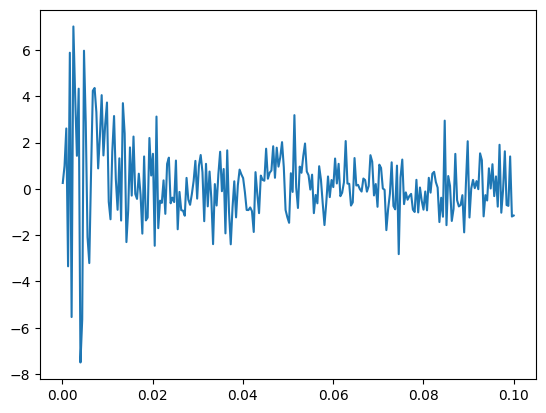

In [9]:
plt.plot(experiment.noise_model.frequencies, data[0])

In [10]:
prior_draws_params = prior_model.sample(jr.key(8123), batch_shape=(10000,), return_array=True)
param_names = prior_model.param_names

model_key = jr.key(1234)
model = make_model(
    model_key,
    flow_layers=6,
    ts_length=noise_model.frequencies.shape[0],
    embedding_dim=32,
    param_dim=prior_draws_params.shape[-1],
    param_mean=prior_draws_params.mean(axis=0),
    param_std=prior_draws_params.std(axis=0),
    param_names=param_names,
    nn_depth=4,
    # transformer=RationalQuadraticSpline(knots=4, interval=(-2, 2))
)

In [11]:
key = jr.key(0)
key, train_key = jr.split(key)
batch_size = 512

model, history = train_online(
    train_key,
    model,
    experiment=experiment,
    batch_fn=batch_fn,
    batch_size=batch_size,
    max_epochs=50,
    steps_per_epoch=100,
    val_steps=4,
    patience=20,
    learning_rate=2e-4,
)

Epoch    0 | train 1.5106 | val 1.0116
Epoch   20 | train -0.0476 | val -0.0285
Epoch   40 | train -0.0911 | val -0.1270


In [12]:
model.config

ModelConfig(ts_length=256, embedding_dim=32, param_dim=2, mlp_width=64, mlp_depth=3, flow_layers=6, nn_width=64, nn_depth=4)

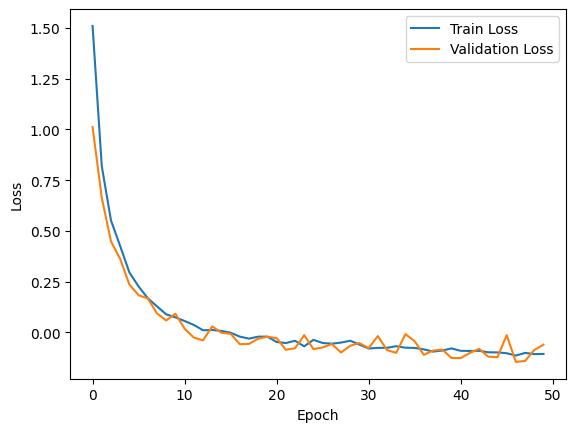

In [13]:
plt.plot(history["train"], label="Train Loss")
plt.plot(history["val"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [14]:
from lisa_sbi_tutorial.model import save_model, load_model

save_model("../models/trained_model", model)
# model_loaded = load_model("../models/trained_model.pkl")

PosixPath('../models/trained_model')

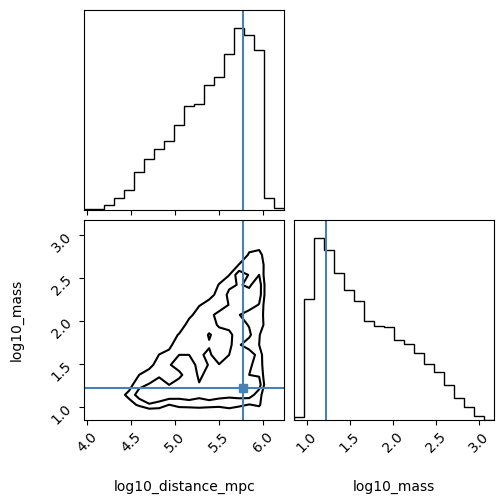

In [15]:
params, data = batch_fn(jax.random.key(1290), experiment, batch_size=1)
params, data = params[0], data[0]

samples = model.sample(jax.random.key(1), n_samples=10_000, condition=data)

kwargs = dict(
    labels=param_names,
    truths=np.array(params),
    fill_contours=False,
    plot_density=False,
    plot_datapoints=False,
    hist_kwargs={"density": True},
    levels=(0.5, 0.9)
)
corner.corner(
    np.array(samples),
    **kwargs
);

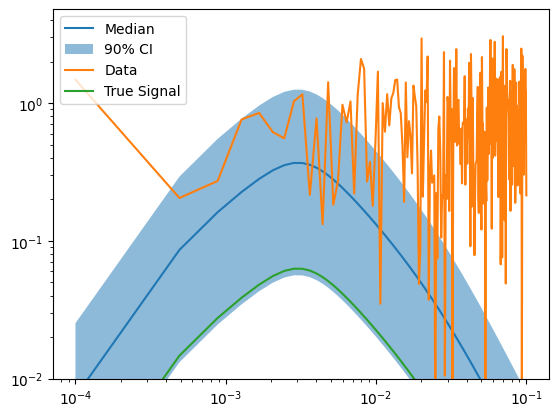

In [16]:
true_signal_whitened = get_whitened_signal(experiment.noise_model.frequencies, params)
signal_whitened = jax.vmap(get_whitened_signal, in_axes=(None, 0))(experiment.noise_model.frequencies, samples)

perc = jnp.percentile(abs(signal_whitened), jnp.array([5, 50, 95]), axis=0)

plt.plot(freqs, perc[1], label="Median")
plt.fill_between(freqs, perc[0], perc[2], alpha=0.5, label="90% CI")
plt.plot(freqs, abs(data), label="Data")
plt.plot(freqs, abs(true_signal_whitened), label="True Signal")
plt.legend()
plt.yscale("log")
plt.ylim(1e-2, None)
plt.xscale("log")